# Module 2: Epidemic Modeling Template

## Team Members:
Kaitlyn Cole and Jake Carnell

## Project Title:
Epidemics

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

##### 2b.1 Importing Graphing and Mathmatical Functions

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

##### 2b.2 Plotting Data and Finding R0

Fitted I0 = 1.2063151589430112
Fitted growth rate r = 0.11982506453515594


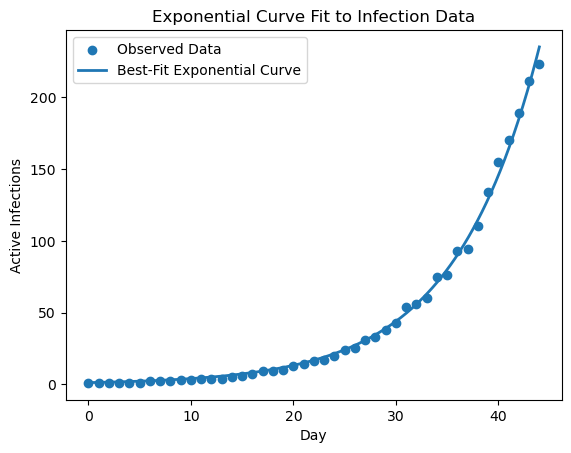

Estimated R0 = 1.239650129070312


In [4]:
data = pd.read_csv('/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

def exponential_growth(t, r):
    return I0 * np.exp(r * t)

data['day'] = (data['date'] - data['date'].min()).dt.days

t = data['day'].to_numpy()
I = data['active reported daily cases'].to_numpy()

def exponential_model(t, I0, r):
    return I0 * np.exp(r * t)


params, covariance = curve_fit(exponential_model, t, I, p0=[I[0], 0.2])

I0_fit, r_fit = params

print("Fitted I0 =", I0_fit)
print("Fitted growth rate r =", r_fit)

t_smooth = np.linspace(min(t), max(t), 300)
I_fit = exponential_model(t_smooth, I0_fit, r_fit)

plt.figure()
plt.scatter(t, I, label='Observed Data')
plt.plot(t_smooth, I_fit, linewidth=2, label='Best-Fit Exponential Curve')
plt.xlabel('Day')
plt.ylabel('Active Infections')
plt.title('Exponential Curve Fit to Infection Data')
plt.legend()
plt.show()

D = 2
R0 = 1 + r_fit * D

print("Estimated R0 =", R0)


##### 2b.3 Initial Conclusions
Our R0 value was 1.24. This is the closest to the seasonal influenza virus that had an R0 value of 1.3. This is a respiratory infection that spreads easily between people. The symptoms are fever, cooughing, and sore throat. The best form of prevention is vaccination.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [5]:
N = 17900
I0 = I[0]
E0 = I0
R0_init = 0
S0 = N - I0 - E0

def euler_SEIR(beta, sigma, gamma):

    S = np.zeros(len(t))
    E = np.zeros(len(t))
    I_model = np.zeros(len(t))
    R = np.zeros(len(t))

    S[0] = S0
    E[0] = E0
    I_model[0] = I0
    R[0] = R0_init

    dt = 1

    for i in range(len(t)-1):

        dS = -beta * S[i] * I_model[i] / N
        dE = beta * S[i] * I_model[i] / N - sigma * E[i]
        dI = sigma * E[i] - gamma * I_model[i]
        dR = gamma * I_model[i]

        S[i+1] = S[i] + dS * dt
        E[i+1] = E[i] + dE * dt
        I_model[i+1] = I_model[i] + dI * dt
        R[i+1] = R[i] + dR * dt

    return S, E, I_model, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [6]:
beta_range = np.linspace(0.1,1.0,15)
sigma_range = np.linspace(0.1,1.0,15)
gamma_range = np.linspace(0.05,0.5,15)

best_SSE = np.inf
best_beta = None
best_sigma = None
best_gamma = None

for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S,E,I_model,R = euler_SEIR(b,s,g)

            SSE = np.sum((I_model - I)**2)

            if SSE < best_SSE:

                best_SSE = SSE
                best_beta = b
                best_sigma = s
                best_gamma = g


print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Lowest SSE =", best_SSE)

Best beta = 0.6142857142857143
Best sigma = 0.3571428571428572
Best gamma = 0.30714285714285716
Lowest SSE = 499.10284452326937


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

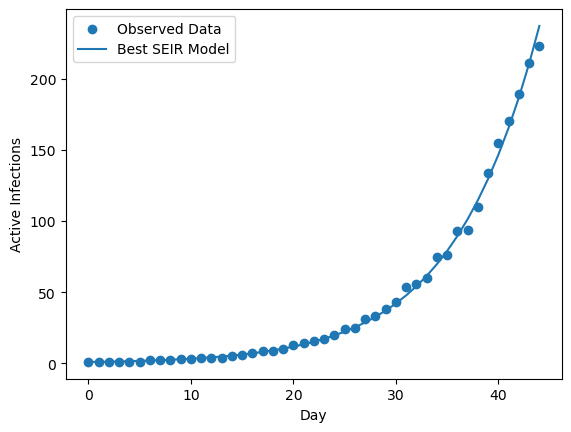

In [7]:
S,E,I_model,R = euler_SEIR(best_beta,best_sigma,best_gamma)

plt.figure()
plt.scatter(t, I, label="Observed Data")
plt.plot(t, I_model, label="Best SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*